In [20]:
using Pkg
Pkg.activate(joinpath(dirname(dirname(@__DIR__))))
#Pkg.update()
# If Sunny library is not installed
# using Pkg
# Pkg.add("Sunny")

  Activating project at `/mnt/graphene/home/jalil2/Documents/Projects2026/TDNEGF`


In [21]:
## Main modules 
using TDNEGF
using DifferentialEquations
using LinearAlgebra

println("Number of threads with JUlIA_NUM used in operations is : " , Threads.nthreads() )
println("Number of threads with BLAS used in operations is : " , BLAS.get_num_threads() )

Number of threads with JUlIA_NUM used in operations is : 1
Number of threads with BLAS used in operations is : 1


In [22]:
#1/(33.0*100 )1e-3
#1/1e4

In [23]:
### Initiallize params for electrons 

function init_params(;Nx::Int=2, Ny::Int=2, Nσ::Int=2, N_orb::Int=1,
                     γ::Float64=1.0, γso=0.05 + 0.0im,Nα = 2, 
                     N_λ1::Int=49, N_λ2::Int=20, β::Float64 = 33.0)#33.0)
    ### Get the poles 
    Rλ, zλ = load_poles_square(N_λ1, N_λ2)
    ####Note that we can initiallize the system only with the dimension of the system 
    p = ModelParamsTDNEGF(Nx   = Nx, Ny   = Ny,  Nσ   = Nσ, N_orb = N_orb, #### dimension
                          Nα   = Nα,  N_λ1 = N_λ1, N_λ2 = N_λ2 ) ;
    ### Now we can assign the real initial values 
    H_ab    = build_H_ab(;Nx = p.Nx,Ny = p.Ny, Nσ = p.Nσ, N_orb = p.N_orb, γ = γ, γso = γso)
    Σᴸ_nλ   = build_Σᴸ_nλ(Rλ, zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β, γ=1.0) ;
    Σᴳ_nλ   = build_Σᴳ_nλ(Rλ, zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β, γ=1.0) ;
    χ_nλ    = build_χ_nλ(zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β, γ=1.0)
    ξ_anR   = build_ξ_an(p.Nx, p.Ny, p.Nσ, p.N_orb; xcol = p.Nx,y_coup = 1:p.Ny)
    ξ_anL   = build_ξ_an(p.Nx, p.Ny, p.Nσ, p.N_orb; xcol = 1,y_coup = 1:p.Ny)
    #### Asigning initial values of the precalculated things
    p.H_ab             .= H_ab
    p.H0_ab            .= H_ab
    p.Δ_α              .= [0.0,0.0] 
    #### Self energies
    p.Σᴸ_nλα[:,:,1]    .= Σᴸ_nλ
    p.Σᴸ_nλα[:,:,2]    .= Σᴸ_nλ
    p.Σᴳ_nλα[:,:,1]    .= Σᴳ_nλ
    p.Σᴳ_nλα[:,:,2]    .= Σᴳ_nλ
    Γ_nλα = 1im*copy(p.Σᴳ_nλα - p.Σᴸ_nλα)
    p.Γ_nλα    .= Γ_nλα
    #1im*(p.Σᴳ_nλα - p.Σᴸ_nλα)
    #### Exponent from poles in the residue theorem 
    p.χ_nλα[:,:,1]     .= χ_nλ
    p.χ_nλα[:,:,2]     .= χ_nλ
    #### Channel vectors 
    p.ξ_anα[:,:,1]     .= ξ_anL
    p.ξ_anα[:,:,2]     .= ξ_anR;
    ####
    p.χ′_nλα  .= conj.(p.χ_nλα)
    p.Σᴸ′_nλα .= conj.(p.Σᴸ_nλα)
    p.Γ′_nλα  .= conj.(p.Γ_nλα);
    return p
end ;

In [24]:
smooth_switch_on(t::Float64;ti=10.0) =t < 0.0 ? 0.0 : (t < ti ? sin((pi/2)*t/ti)^2 : 1) ;

smooth_pulse(t::Float64; ti::Float64=10.0, Δ::Float64=100.0) =
    t < 0.0 ? 0.0 :
    (t < ti ? sin((pi/2)*t/ti)^2 :
    (t < Δ ? 1.0 :
    (t < Δ + ti ? cos((pi/2)*(t-Δ)/ti)^2 : 0.0)))

smooth_pulse (generic function with 1 method)

In [25]:
using Sunny
### Initiallize params for classical spin (Note that sunny.jl package is used)
function init_params_heisenberg_llg(;Nx::Int=2,Ny::Int=2,j_ex::Float64=0.1,a0::Float64=1.0,j_ani::Float64=0.01,Bx::Float64=1e-5)
    latvecs   = lattice_vectors(a0, a0, 4*a0, 90, 90, 90)  # cúbica
    positions = [[0.5, 0.5, 0.0]] 
    # Define the symmtery of the crystal 
    cryst = Crystal(latvecs, positions)
    # Characterizes an effective spin magnetic moment on an atom
    # specification of spi moments
    moments = [1 => Moment(s=1.0, g=1.0)]
    # creates an instance of spin moments
    sys = System(cryst, moments, :dipole; dims=(Nx, Ny, 1)) 
    # Heisenberg interaction 
    set_field!(sys,[Bx,0.0,0.0])
    set_exchange!(sys, j_ex, Bond(1, 1, [1, 0, 0]))  # vecino +x
    set_exchange!(sys, j_ex, Bond(1, 1, [0, 1, 0]))  # vecino +y
    set_onsite_coupling!(sys, S ->  -j_ani*S[3]^2, 1)
    
   # set_onsite_coupling!(sys, S -> -Bx*S[1], 1)
    sys = to_inhomogeneous(sys)
    remove_periodicity!(sys, (true, true, true)) 
    
    
    ### Initial state
    if j_ex >= 0.0 #(+ is antiferro)
        for I in eachindex(sys.dipoles)
            i,j=ij_from_linear(I,Ny)
            sys.dipoles[I] = Sunny.SVector(0.0, 0.0, (-1)^(i+j) )  
        end
    else  #(- is ferro)
        for I in eachindex(sys.dipoles)
            
            sys.dipoles[I] = Sunny.SVector(0.0, 0.0, 1.0)  ### AFM configuration
        end
    end

    return sys
end

@inline linear_index(i::Int, j::Int, Ny::Int) = (i - 1) * Ny + j

@inline function ij_from_linear(l::Int, Ny::Int)
    i = (l - 1) ÷ Ny + 1
    j = (l - 1) % Ny + 1
    return i, j
end
### Update the classical Hamiltonian
function update_H_s!(Nx::Int,Ny::Int,sys::System{0},σx_i::Array{Float64, 2}, j_sd::Float64,B0::Vector{Float64}=[0.0, 0.0, 0.0] )
    #B0 = sys.extfield[1,1,1,1] #### Take the global field
    @inbounds for i in 1:Nx for j in 1:Ny
        idx = linear_index(i,j,Ny) ### include the spin degree of freedom
        sden = -σx_i[idx,:]*j_sd
        set_field_at!(sys, sden .+ B0 ,(i , j, 1, 1)) 
        #println(i,j)
    end end
    return nothing 
end
# sys = init_params_heisenberg_llg(j_ex = -0.05,j_ani=0.001,Bx=1e-5)
# sys.dipoles
#sys = init_params_heisenberg_llg(Nx = 3 ,Ny = 3, j_ex = 0.1)
# sys.dipoles

update_H_s! (generic function with 2 methods)

In [31]:
#using GLMakie
# fig = GLMakie.Figure(size = (800, 600))
# ax  = GLMakie.Axis3(fig[1, 1])
# hidedecorations!(ax, grid = true)    # quita ticks, labels, etc.
# hidespines!(ax)         # quita el cubo/bordes
# # 3. Ajusta la cámara del Axis3: x → derecha, z ↑
# ax.azimuth[]   = 0.3pi/2           # 0°
# ax.elevation[] = 0.08pi          # 30°
# Sunny.plot_spins!(
#     ax, sys;
#     color     = [S[3] for S in sys.dipoles] , arrowscale=0.3,show_cell=false,ndims=2, stemcolor=:lightgray
# )
# # --- fijar límites constantes ---
# N = size(sys.dipoles, 1)          # asumiendo dims = (N,1,1,1)
# fixed_limits = ((-1,  5+1.0),   # x
#                 (-2.2, 4.1),      # y
#                 (-0.9, 0.9))      # z

# ax.limits[] = fixed_limits
# fig   

## Evolution

In [33]:
function spin_dynamics_and_electrons_evolution(t_0::Float64, Δt::Float64 ,t_end::Float64;j_sd::Float64 = 0.1,
        j_ex::Float64 = 0.1,j_ani::Float64=0.1,Bx::Float64=0.0,u0=nothing,m0=nothing)
    println("Join the Main function")
    p   = init_params()
    u0 === nothing ? nothing : p.u .= u0
   
    sys = init_params_heisenberg_llg(Nx = 2 ,Ny = 2, j_ex = j_ex, j_ani = j_ani, Bx=Bx)
    #minimize_energy!(sys)
    
    m0 === nothing ? nothing : sys.dipoles .= m0
    p.Δ_α     .= [0.0,-0.0] 
    ### Setting the integrator for electrons
    prob       =  ODEProblem(eom_tdnegf!,p.u, (t_0,t_end), p )
    intg       =  init(prob,Vern7(),dt = Δt, save_everystep=false,adaptive=true,dense=false)#, reltol=1e-6, abstol=1e-8)#, verbose= true)
    integ      =  Langevin(Δt ; damping = 0.5, kT=0.0) #1e-6
    println("The integrator has been set")
    N_steps      = Int(round((t_end - t_0)/Δt))
    obs = ObservablesTDNEGF(p; N_tmax=N_steps , N_leads = p.Nα)
    site_ranges_couple = [get_sub(i, p.N_loc) for i in [1,2,3,4]]
    update_H_e!(p, site_ranges_couple, sys.dipoles[:,:,1,1], j_sd*0.0)
    ####site_ranges_couple = [get_sub(i, p.N_loc) for i in [5,6,7,8]]
    #site_ranges_couple = [get_sub(i, p.N_loc) for i in 1:p.Nx*p.Ny]
    ### Setting the initial Barrier
    # for i in [collect(1:2p.Ny) ; collect(p.Ny*p.Nx-2p.Ny:p.Ny*p.Nx)]
    #     ### Time independent hamiltonian
    #     p.H0_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*50
    #     ### Time dependent hamiltonian
    #     p.H_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)]  .= I(2)*50
    # end
    obs.t = collect(t_0:Δt:(t_end-Δt))
    ### loop evolution 
    @time for (i,t) in enumerate(t_0:Δt:(t_end-Δt))
        obs.idx = i
        println("time: ", round(i*Δt,digits=2))
        flush(stdout)
        ## Initial time evolution 
        DifferentialEquations.step!(intg, Δt, true)
        #Sunny.step!(sys,integ)
        
        dv =  TDNEGF.pointer(intg.u ,p)  
        obs_n_i!(dv, p, obs)            ### Charge density
        obs_σ_i!(dv, p, obs)            ### Spin density 
        obs_Ixα!(dv, p, obs)            ### Spin and charge current ##old Pi is used? when reestart dynamics?
        obs_s_i!(sys.dipoles[:,:,1,1], p, obs)

        ### Update Hamitonians
        #update_H_s!(2,p.Ny,sys,obs.σx_i[:,:,obs.idx], j_sd, [Bx,0.0,0.0] )    ### Update the Hamiltonian  of classical dynamics
        #update_H_e!(p, site_ranges_couple, sys.dipoles[:,:,1,1], j_sd*0.0)         ### Update the Hamiltonian electron dynamics 

        # if t<= 300 
        #      minimize_energy!(sys)
        # end
            
        

        # if t ≈ 50.0 # Turn off Barrier
        #     println("Turn off Barrier")
        #     for i in [collect(1:2p.Ny) ; collect(p.Ny*p.Nx-2p.Ny:p.Ny*p.Nx)]
        #         p.H0_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*0.0
        #         p.H_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*0.0
        #     end
        # end
        p.Δ_α .= [smooth_pulse(t .-100.0;ti=10.0,Δ=1000.0)*0.8 , 0.0 ] ### 1 is okay maybe less to not polarize it completely
        # if t<=200.0 
            # p.Δ_α .= [smooth_switch_on(t-100;ti=10.0)*1.0 ,
            #          -smooth_switch_on(t-100;ti=10.0)*0.0 ]
        # else  # Turn off bias voltage
        #     #println("Turn off bias voltage")
        #     p.Δ_α     .= [0.0, 0.0]
        # end
    end #end evolution loop 
    return  obs, intg.u#, sys.dipoles ### we are also saving the final state 
end

spin_dynamics_and_electrons_evolution (generic function with 1 method)

In [34]:
# using JLD2
# @load "./state_spin_dynamics_and_electrons_fm_j_ex=0_05_j_sd=0_1_j_ani=0_01_damp=10.jl2" state

In [6]:
# Load and save data 
#using JLD2
#obs42, u_042= spin_dynamics_and_electrons_evolution(0.0,0.1,200.0; j_ex = -0.05,j_sd = 0.4,j_ani=1e-4,Bx=-1e-5)#,u0=u_03, m0=m_03)
#save "./state_spin_dynamics_and_electrons_fm_j_ex=0_05_j_sd=0_1_j_ani=0_01_damp=10.jl2" state

In [37]:
using PyPlot
plt.rc("axes", linewidth=2)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text
fs=25

25

In [66]:
### Lets plot the AFM against the FM configuration 
# Calculation of the average magnetization for FM configuration
function avg_M(dip::Array{Float64, 3},Nx::Int,Ny::Int)
    size_t   = size(dip)[3]
    size_sys = Nx*Ny#size(dip)[1]
    M_t      = zeros(Float64,3,size_t)
    for t_idx in 1:size_t
        for i in 1:size_sys
            for x in 1:3
                M_t[x,t_idx] +=  dip[i ,x,t_idx]
            end
        end
    end
    return M_t/size_sys
end
# Calculation of the average Neel Vector for AFM configuration
function avg_N(dip::Array{Float64, 3},Nx::Int,Ny::Int)
                
    size_t   = size(dip)[3]
    size_sys = Nx*Ny
    N_t      = zeros(Float64,3,size_t)
    for t_idx in 1:size_t
        for i in 1:size_sys
            i_x,j_y = ij_from_linear(i,Ny)
            for x in 1:3
                N_t[x,t_idx] +=  dip[i ,x,t_idx]*(-1)^(i_x+j_y)
            end
        end
    end
    return N_t/size_sys

end

avg_N (generic function with 1 method)

In [1]:
# plt.plot(obs42.t,M_FM[1,:])
# plt.plot(obs42.t,M_FM[2,:])
# plt.plot(obs42.t,M_FM[3,:])
#plt.xlim(600,800)
#plt.xlim(7500,8000)

In [2]:
# plt.plot(obs4.t,M_FM[1,:])
# plt.plot(obs4.t,M_FM[2,:])
# plt.plot(obs4.t,M_FM[3,:])
# plt.xlim(90,1500)

In [3]:
# plt.plot(obs4.t,M_FM[1,:])
# plt.plot(obs4.t,M_FM[2,:])
# plt.axvline(200)
# plt.plot(obs42.t,M_FM[3,:])
#plt.xlim(100,300)

In [4]:
#plt.plot(obs4.t,M_FM[3,:])

In [5]:
#state = [obs3,u_03,m_03]

In [7]:
# #fig,axs =  plt.subplots(2,2,figsize=(9,8))

# plt.plot(obs_FM.t,M_FM[1,:])
# plt.plot(obs_FM.t,M_FM[2,:])
# plt.plot(obs_FM.t,M_FM[3,:])

# plt.plot(obs_AFM.t,obs_AFM.Iα[1,:]*0.5, label = raw"$\mathrm{I_R}$")  
#plt.xlim(1000,2000)

#plt.axhline(M_FM[1,16968],color=)

#M_FM[1,16968]
#plt.xlim(7500,8000)

In [143]:
#findall(x -> x ==-0.4838367754173424,M_FM[1,:])

In [8]:
# fig,axs =  plt.subplots(2,2,figsize=(9,8))
# ############---------------------------------------------------
# axs[1,1].set_ylabel(raw"$\mathrm{M^{\alpha}}$", fontsize = fs)
# axs[1,1].plot(obs_FM.t,M_FM[1,:],color = "blue")
# axs[1,1].plot(obs_FM.t,M_FM[2,:],color = "green")
# axs[1,1].plot(obs_FM.t,M_FM[3,:],color = "red")
# #axs.plot(obs_FM.t,obs_AFM.sx_i[2,1,:],color = "blue")
# ############---------------------------------------------------
# axs[2,1].set_ylabel(raw"$\mathrm{I^{S_{\alpha}}_L\ (e\gamma/h)}$", fontsize = fs)
# axs[2,1].set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
# axs[2,1].plot(obs_FM.t,obs_FM.Iαx[2,1,:], label = raw"$\mathrm{\alpha = x}$",color="blue")
# axs[2,1].plot(obs_FM.t,obs_FM.Iαx[2,3,:], label = raw"$\mathrm{\alpha = z}$",color="red")
# axs[2,1].plot(obs_FM.t,obs_FM.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",color="green")
# axs[2,1].set_ylim(-1e-2,4e-2)
# #axs[2,1].set_xlim(0,500)
# ############---------------------------------------------------
# axs[1,2].set_ylabel(raw"$\mathrm{N^{\alpha}}$", fontsize = fs)
# axs[1,2].plot(obs_AFM.t,N_AFM[1,:],color = "blue")
# axs[1,2].plot(obs_AFM.t,N_AFM[3,:],color = "red")
# axs[1,2].plot(obs_AFM.t,N_AFM[2,:],color = "green")
# #axs[2,1].set_xlim(0,500)
# ############---------------------------------------------------
# axs[2,2].set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
# axs[2,2].plot(obs_AFM.t,obs_AFM.Iαx[2,1,:], label = raw"$\mathrm{\alpha = x}$",color="blue")
# axs[2,2].plot(obs_AFM.t,obs_AFM.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",color="green")
# axs[2,2].plot(obs_AFM.t,obs_AFM.Iαx[2,3,:], label = raw"$\mathrm{\alpha = z}$",color="red")

# axs[2,2].set_ylim(-1e-2,4e-2)

# index = [raw"$\rm{(a)}$",raw"$\rm{(c)}$",raw"$\rm{(b)}$",raw"$\rm{(d)}$",raw"$\rm{(e)}$",raw"$\rm{(f)}$",raw"$\rm{(g)}$",raw"$\rm{(h)}$" ]
# i=1
# for ax in axs
#     ax.set_xlim(0,4000)
#     ax.text(x=0.92, y=0.805, s=index[i],fontsize=fs,ha="center", transform=ax.transAxes)
#     ax.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
#     ax.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
#     ax.yaxis.offsetText.set_fontsize(fs)
#      i=i+1
# end

# axs[1].set_xticklabels([ ])
# axs[3].set_xticklabels([ ])

# #plt.tight_layout()
# axs[2].legend(frameon = false, fontsize = fs-12, loc= (0.125,  0.92),ncol =3,columnspacing=0.2)

# axs[1].annotate(raw"$\mathrm{FM}$", xy=(0.5, 1.08), xytext=(0.5, 1.2), xycoords="axes fraction", 
#            fontsize=fs, ha="center", va="top", rotation=0.0,
#            arrowprops=Dict("arrowstyle"=>"-[, widthB=5.0, lengthB=0.2", "lw"=>1.0))

# axs[3].annotate(raw"$\mathrm{AFM}$", xy=(0.5, 1.08), xytext=(0.5, 1.2), xycoords="axes fraction", 
#            fontsize=fs, ha="center", va="top", rotation=0.0,
#            arrowprops=Dict("arrowstyle"=>"-[, widthB=5.0, lengthB=0.2", "lw"=>1.0))

# plt.tight_layout()



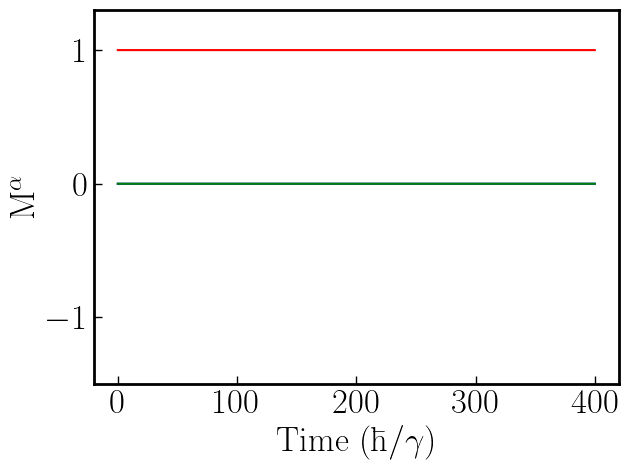

In [67]:

fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,2)
# for site in sites
#    # obs2.t .+obs.t[end]
#     axs.plot(obs.t,obs.sx_i[site,1,:])#,alpha =1-0.2*i ) ### Charge bound current
#     #axs.plot(obs.t,obs.sx_i[site,2,:],label= raw"$\alpha=y$ ")
#     #axs.plot(obs.t,obs.sx_i[site,3,:],label= "site=$(site)")
#    # axs.plot(obs2.t .+obs.t[end],obs2.sx_i[site,3,:],label= raw"$\alpha=z$ ")
# end
# axs.plot(obs_AFM.t,obs_AFM.sx_i[1,1,:],color = "red")
# axs.plot(obs_AFM.t,obs_AFM.sx_i[2,1,:],color = "blue")

# axs.plot(obs_AFM.t,obs_AFM.sx_i[3,1,:],color = "red")
# axs.plot(obs_AFM.t,obs_AFM.sx_i[4,1,:],color = "blue")

# axs.plot(obs.t,obs.sx_i[1,2,:],color = "red",ls = ":")
# axs.plot(obs.t,obs.sx_i[2,2,:],color = "blue",ls = ":")

#axs.plot(obs.t,obs.sx_i[1,3,:],color = "red",ls = "-")
#axs.plot(obs.t,obs.sx_i[2,3,:],color = "blue",ls = "-")


#axs.plot(obs.t,obs.sx_i[site,1,:],color = "blue",ls = "-")
#axs.plot(obs.t,obs.sx_i[site,2,:],color = "green",ls = "-")
#axs.plot(obs.t,obs.sx_i[site,2,:],color = "red",ls = "-")
#axs.plot(obs3.t ,obs3.sx_i[site,3,:],color = "yellow",ls = "-")
#axs.plot(obs2.t .+ obs1.t[end] .+ obs.t[end],obs2.sx_i[site,2,:],color = "orange",ls = "-")

#axs.plot(obs3.t .+ obs2.t[end] .+ obs1.t[end] .+ obs.t[end],obs3.sx_i[site,2,:],color = "blue",ls = "-")
#axs.plot(obs4.t  ,obs4.sx_i[site,3,:],color = "black",ls = "-")
#axs.plot(obs_AFM.t,obs_AFM.sx_i[4,3,:],color = "red",ls = "--")


axs.plot(obs42.t  ,obs42.sx_i[1,1,:],color = "blue",ls = "-")
axs.plot(obs42.t  ,obs42.sx_i[1,2,:],color = "green",ls = "-")
axs.plot(obs42.t  ,obs42.sx_i[1,3,:],color = "red",ls = "-")

# axs.plot(obs4.t  ,obs4.sx_i[4,3,:],color = "blue",ls = "-")
# axs.plot(obs4.t  ,obs4.sx_i[5,3,:],color = "green",ls = "-")
# axs.plot(obs4.t  ,obs4.sx_i[6,3,:],color = "red",ls = "-")


#axs.plot(obs4.t  ,obs4.sx_i[7,3,:],color = "blue",ls = "-")
#axs.plot(obs4.t  ,obs4.sx_i[2,1,:],color = "green",ls = "-")
#axs.plot(obs4.t  ,obs4.sx_i[9,3,:],color = "red",ls = "-")

#axs.plot(obs4.t  ,obs4.sx_i[3,1,:],color = "green",ls = "-")


# axs.plot(obs_AFM.t,obs_AFM.sx_i[3,3,:],color = "red",ls = "-")
# axs.plot(obs_AFM.t,obs_AFM.sx_i[4,3,:],color = "blue",ls = "-")
# line1 = plt.plot([0, 1], [0, 1], color="red",ls="-")[1]
# line2 = plt.plot([0, 1], [1, 0], color="blue",ls="-")[1]
# line3 = plt.plot([0, 1], [1, 0], color="black",ls="-")[1]
# line4 = plt.plot([0, 1], [1, 0], color="black",ls="--")[1]
# lg2 = axs.legend([line1, line2, line3, line4], [raw"$\rm{i \in A}$", raw"$\rm{i \in B}$", raw"$\rm{\alpha=x}$", raw"$\rm{\alpha=z}$"]
#                 ,frameon = false, fontsize = fs-10, loc= (0.05,  0.9),ncol =4,columnspacing=0.5)
# axs.add_artist(lg2)

tss=0.0:0.1:1200
#plt.plot(tss,smooth_pulse.(tss .-200.0;ti=30.0,Δ=800.0)*0.5.-1.5,color="gray")

axs.set_ylabel(raw"$\mathrm{M^{\alpha}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#axs.axvline(50)
#axs.axvline(150)
#plt.xlim(0,150)
#axs.text(x=0.08, y=0.1, s = raw"$\mathrm{Vb}$",fontsize=fs-2,ha="center", transform=axs.transAxes,color="gray")
#plt.xlim(0,800)

#smooth_pulse(t .-200.0;ti=30.0,Δ=800.0)
#plt.xlim(0,1200)
plt.ylim(-1.5,1.3)
plt.tight_layout()

In [9]:
# fig,axs = plt.subplots(1,1)
# axs.plot(obs42.t,obs42.Iα[1,:]*pi, label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
# axs.plot(obs42.t,obs42.Iα[2,:]*pi, label = raw"$\mathrm{I_L}$")
# #axs.plot(obs.t,obs.Iα[2,:]*pi .+ obs.Iα[1,:]*pi , label = raw"$\mathrm{I_T}$")


# # axs.plot(obs2.t .+obs.t[end],obs2.Iα[1,:]*pi, label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
# # axs.plot(obs2.t .+obs.t[end],obs2.Iα[2,:]*pi, label = raw"$\mathrm{I_L}$")
# #axs.plot(obs2.t .+obs.t[end],obs2.Iα[2,:]*pi .+ obs.Iα[1,:]*pi , label = raw"$\mathrm{I_T}$")
# #axs.axhline(1)
# #axs.axhline(-0.1)

# axs.set_ylabel(L"$\mathrm{I\ (2e\gamma/h)}$", fontsize = fs)
# axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
# axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
# axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
# axs.yaxis.offsetText.set_fontsize(fs)
# #axs.set_ylim(-1e-4,1e-4)
# plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))

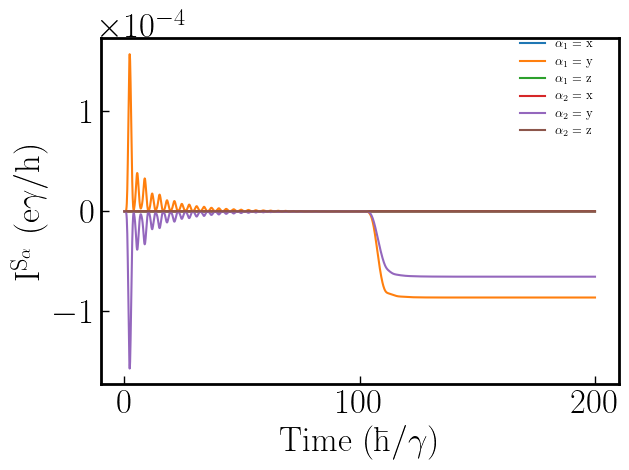

In [94]:
fig,axs = plt.subplots(1,1)
axs.plot(obs42.t,obs42.Iαx[2,1,:], label = raw"$\mathrm{\alpha_1 = x}$")
axs.plot(obs42.t,obs42.Iαx[2,2,:], label = raw"$\mathrm{\alpha_1 = y}$",ls="-")
axs.plot(obs42.t,obs42.Iαx[2,3,:], label = raw"$\mathrm{\alpha_1 = z}$")
#axs.plot(obs4.t,obs4.Iαx[1,1,:], label = raw"$\mathrm{\alpha = z}$")

axs.plot(obs42.t,obs42.Iαx[1,1,:], label = raw"$\mathrm{\alpha_2 = x}$")
axs.plot(obs42.t,obs42.Iαx[1,2,:], label = raw"$\mathrm{\alpha_2 = y}$",ls="-")
axs.plot(obs42.t,obs42.Iαx[1,3,:], label = raw"$\mathrm{\alpha_2 = z}$")

#axs.plot(obs2.t .+ obs1.t[end] .+ obs.t[end],obs2.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")



#axs.plot(obs3.t .+ obs2.t[end] .+ obs1.t[end] .+ obs.t[end],obs3.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")


#axs.plot(obs_AFM.t,obs_AFM.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")

# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,1,:], label = raw"$\mathrm{\alpha = x}$")
# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")

#axs.plot(obs.t,obs.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")

#axs.plot(obs.t,obs.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
axs.set_ylabel(raw"$\mathrm{I^{S_{\alpha}}\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.axhline(0.08)
plt.legend(frameon = false, fontsize = fs-16, loc= (0.8,  0.7))
#axs.set_ylim(-8e-2,2e-2)
#axs.set_ylim(-2e-5,2e-5)
#axs.set_ylim(-2e-5,3e-5)
#plt.xlim(80,500)
plt.tight_layout()

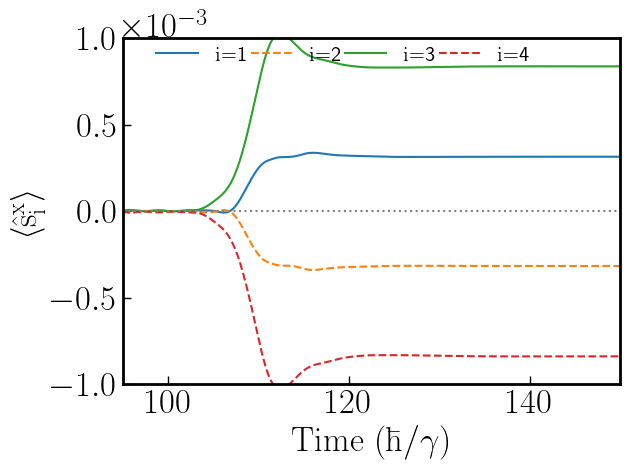

In [65]:


fig,axs =  plt.subplots(1,1)
site = 1
sites = [3,4,5,6,7,8,9,10]#3:1:9#[6,8,5,7]#
#2:2:12#range(1,4)


axs.plot(obs42.t,obs42.σx_i[1,1,:],label= L"$\mathrm{i}$=1")

axs.plot(obs42.t,obs42.σx_i[2,1,:],label= L"$\mathrm{i}$=2",ls="--")



axs.plot(obs42.t,obs42.σx_i[3,1,:],label= L"$\mathrm{i}$=3")

axs.plot(obs42.t,obs42.σx_i[4,1,:],label= L"$\mathrm{i}$=4",ls ="--")


#axs.text(x=0.15, y=0.12, s = raw"$\mathrm{V_b}$",fontsize=fs-5,ha="center", transform=axs.transAxes,color="gray")
#tss = 0.0:0.1:500
#plt.plot(tss,smooth_pulse.(tss .-100.0;ti=10.0,Δ=800.0)*1e-2.-3e-2,color="gray")
plt.axhline(0.0,color="gray",ls = ":")

 ###Y stationary components with Tkwant
# plt.axhline(0.0229,color="gray",alpha=0.5)
# plt.axhline(0.0148,color="gray",alpha=0.5)
# plt.axhline(-0.0138,color="magenta",alpha=0.5,ls = "-")
# plt.axhline(0.0138,color="magenta",alpha=0.5,ls = "-")
#plt.axhline(0.0256087)


#axs.text(x=0.15, y=0.12, s = raw"$\mathrm{V_b}$",fontsize=fs-5,ha="center", transform=axs.transAxes,color="gray")
plt.ylim(-1e-3,1e-3)

#plt.ylim(-0.00003,0.00003)
#plt.xlim(95,150)
axs.set_ylabel(raw"$\langle\mathrm{\hat{s}^{x}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.05,  0.9),ncols =4 ,columnspacing =0.2 )
#plt.xlim(390,800)
plt.xlim(95,150)

# -4.0140344740180554e-05
# -4.024588167972822e-05
# -3.714238119982978e-05
# -3.770439956140108e-05
#plt.axhline(0.00010879634042492944*2pi,color = "magenta")
# ---------------
# 6.7683451945385e-05
# 8.679951441103618e-05
# 0.00010879634042492944
# 4.603579532587061e-05
# plt.axhline(6.33110856e-04)
# plt.axhline(2.19645491e-05 )
#plt.axhline(0.008444688228137934/10)
plt.axhline(0.0011454578975767923)
#plt.axhline(6.08739656e-05)
#plt.xlim(190,300)
#plt.xlim(395,500)
plt.tight_layout()

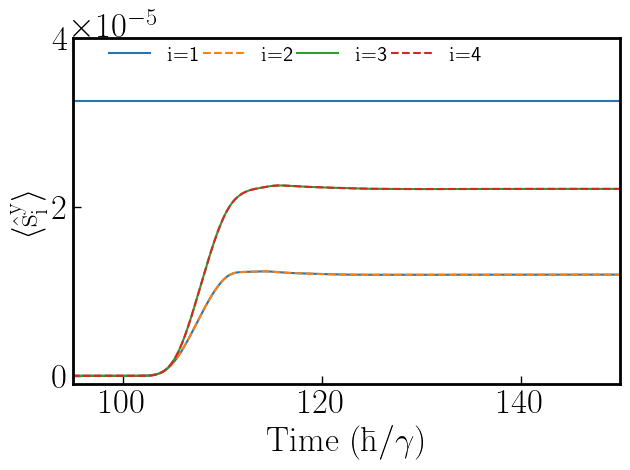

In [56]:


fig,axs =  plt.subplots(1,1)
site = 1
sites = [3,4,5,6,7,8,9,10]#3:1:9#[6,8,5,7]#
#2:2:12#range(1,4)


axs.plot(obs42.t,obs42.σx_i[1,2,:],label= L"$\mathrm{i}$=1")

axs.plot(obs42.t,obs42.σx_i[2,2,:],label= L"$\mathrm{i}$=2",ls="--")



axs.plot(obs42.t,obs42.σx_i[3,2,:],label= L"$\mathrm{i}$=3")

axs.plot(obs42.t,obs42.σx_i[4,2,:],label= L"$\mathrm{i}$=4",ls ="--")


#axs.text(x=0.1, y=0.1, s = raw"$\mathrm{V_b}$",fontsize=fs-5,ha="center", transform=axs.transAxes,color="gray")
#tss = 0.0:0.1:500
#plt.plot(tss,smooth_pulse.(tss .-100.0;ti=10.0,Δ=800.0)*1e-2.-1e-2,color="gray")
#plt.axhline(0.0,color="gray",ls = ":")

 ###Y stationary components with Tkwant
# plt.axhline(0.0229,color="gray",alpha=0.5)
# plt.axhline(0.0148,color="gray",alpha=0.5)

#plt.axhline(0.0150,color="magenta",alpha =0.5)
#plt.axhline(0.00648195)
#plt.ylim(-5e-2,9e-2)
#plt.ylim(-0.00001,0.00003)
plt.axhline( 3.25401971e-05)

#plt.xlim(95,150)
axs.set_ylabel(raw"$\langle\mathrm{\hat{s}^{y}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.05,  0.9),ncols =4 ,columnspacing =0.2 )
plt.ylim(-0.1e-5,4e-5)
plt.xlim(95,150)
#plt.xlim(10,1200)
plt.tight_layout()

In [123]:
# ?plt.legend

# [-9.53415617e-05  9.53415617e-05  9.53415617e-05 -9.53415617e-05]
# [0.00052611 0.00052611 0.00052611 0.00052611]
1/4.3

0.23255813953488372

In [129]:
1/4

0.25

In [10]:


# fig,axs =  plt.subplots(1,1)
# site = 1
# sites = [3,4,5,6,7,8,9,10]#3:1:9#[6,8,5,7]#
# #2:2:12#range(1,4)


# axs.plot(obs42.t,obs42.σx_i[1,2,:],label= "site=1")

# axs.plot(obs42.t,obs42.σx_i[2,2,:],label= "site=2",ls="--")



# axs.plot(obs42.t,obs42.σx_i[3,2,:],label= "site=3")

# axs.plot(obs42.t,obs42.σx_i[4,2,:],label= "site=4",ls ="--")


# # axs.plot(obs42.t,obs42.σx_i[7,2,:],label= "site=7")

# # axs.plot(obs42.t,obs42.σx_i[8,2,:],label= "site=8",ls ="--")


# # axs.plot(obs42.t,obs42.σx_i[9,2,:],label= "site=9")

# # axs.plot(obs42.t,obs42.σx_i[10,2,:],label= "site=10",ls ="--")
# # for site in sites
    
# #     #axs.plot(obs2.t,obs2.σx_i[site,1,:],label= "site=$(site)")#,alpha =1-0.2*i ) ### Charge bound current
# #     #axs.plot(obs.t,obs.σx_i[site,2,:],label= raw"$\alpha=y$ ")
# #     #axs.plot(obs.t,obs.σx_i[site,1,:],label= "site=$(site)")
# #     #axs.plot(obs.t,obs.σx_i[site,2,:],label= "site=$(site)")
# #     axs.plot(obs42.t,obs42.σx_i[site,2,:],label= "site=$(site)")
# #     #axs.plot(obs.t[end] .+ obs1.t,obs1.σx_i[site,1,:],label= "site=$(site)")
# #     #axs.plot(obs2.t .+ obs1.t[end] .+ obs.t[end],obs2.σx_i[site,1,:],label= "site=$(site)")
# #     #axs.plot( obs3.t .+ obs2.t[end] .+ obs1.t[end] .+ obs.t[end],obs3.σx_i[site,1,:],label= "site=$(site)")
# #     #obs3.t .+ obs2.t[end] .+ obs1.t[end] .+ obs.t[end]
    
# #     #axs.plot(obs2.t .+obs.t[end],obs2.σx_i[site,3,:],label= raw"$\alpha=z$ ")
# # end
# axs.text(x=0.2, y=0.1, s = raw"$\mathrm{V_b}$",fontsize=fs-5,ha="center", transform=axs.transAxes,color="gray")

# #plt.plot(tss,smooth_pulse.(tss .-100.0;ti=15.0,Δ=800.0)*1e-2.-3e-2,color="gray")
# plt.axhline(0.0,color="gray",ls = ":")
# # plt.axhline(0.0245,color="gray",alpha=0.5)
# # plt.axhline(0.0145,color="gray",alpha=0.5)


# # 0.008965418930676773
# # -0.016998949654715108
# # -0.035600785929999976
# # -0.009236516419625918
# # ---------------
# # -0.0010338972613759352
# # -0.024111385347690268
# # -0.003509300295657198
# # -0.021491875058176402

# # plt.axhline(0.008965418930676773)
# # plt.axhline(-0.016998949654715108)
# # plt.axhline(-0.035600785929999976)
# # plt.axhline(-0.009236516419625918)
# #----------------------
# # plt.axhline(-0.0010338972613759352)
# # plt.axhline(-0.024111385347690268)
# # plt.axhline(-0.003509300295657198)
# # plt.axhline(-0.021491875058176402)



# #plt.axhline(0.008965418930676773)
# plt.ylim(-0.04,0.04)
# plt.xlim(95,150)
# axs.set_ylabel(raw"$\langle\mathrm{\hat{s}^{y}_i}\rangle$", fontsize = fs)
# axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
# axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
# #axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
# axs.yaxis.offsetText.set_fontsize(fs)
# plt.legend(frameon = false, fontsize = fs-15, loc= (0.8,  0.5))
# #plt.xlim(10,1200)
# plt.tight_layout()

In [97]:
#plt.plot(obs4.σx_i[7,3,1:500])